# Customer Churn Prediction  Multi-Algorithm Classification Showdown
**Dataset:** IBM Telco Customer Churn | **Task:** Supervised Learning � Binary Classification (Churn: Yes/No)

This notebook builds and compares KNN, Naive Bayes, SVM, and Decision Tree classifiers to predict customer churn for a telecom retention team, in line with the practical exam requirements.

## Step 1: Problem Framing & Theory Notes

**1. What is Customer Churn? Why is predicting it valuable?**
- Customer churn is when a paying subscriber stops using a company's service (e.g., cancels their telecom plan).
- For a business like Jio or Airtel, predicting churn lets the retention team intervene (discounts, calls, offers) *before* the customer leaves.
- It is valuable because Customer Acquisition Cost (CAC)  the cost of marketing/onboarding a new subscriber  is far higher than Customer Lifetime Value (CLV) retention spend. Retaining an existing customer is cheaper than acquiring a new one to replace them, so churn prediction directly protects revenue.

**2. Confusion Matrix  Four Cells & Business Cost**
- **TP (True Positive):** Model correctly predicts a customer *will* churn, and they do.
- **TN (True Negative):** Model correctly predicts a customer will *stay*, and they do.
- **FP (False Positive):** Model predicts churn, but the customer actually stays. Cost: a wasted retention offer (discount given unnecessarily)  a moderate, recoverable cost.
- **FN (False Negative):** Model predicts the customer will *stay*, but they actually churn. Cost: the company loses a paying customer with **no warning and no chance to intervene**  this is the most expensive error because the lost revenue (CLV) is rarely recovered.

**3. Class Imbalance & SMOTE**
- Class imbalance occurs when one class (here, "No Churn") vastly outnumbers the other ("Churn"). The Telco dataset has roughly 73% "No" vs 27% "Yes"  a moderate imbalance.
- This biases models toward predicting the majority class, hurting recall on the minority (Churn) class  exactly the class the business cares most about.
- **SMOTE** (Synthetic Minority Oversampling Technique) addresses this by generating synthetic examples of the minority class (interpolating between existing churn examples' nearest neighbors) rather than just duplicating rows, giving the model more balanced exposure during training.

**4. How each algorithm works**
- **KNN (K-Nearest Neighbors):** Classifies a new customer by looking at the 'k' most similar existing customers (by distance in feature space) and taking a majority vote of their churn labels. No real "training"  it memorizes the data and computes distances at prediction time.
- **Naive Bayes:** Uses Bayes' theorem to compute the probability of churn given the feature values, assuming all features are conditionally independent given the class. Fast and works well as a baseline, even though the independence assumption is rarely fully true.
- **SVM (Support Vector Machine):** Finds the optimal hyperplane (boundary) that maximally separates churners from non-churners in feature space, using kernel tricks (e.g., RBF) to handle non-linear boundaries.
- **Decision Tree:** Recursively splits the data on the feature/threshold that best separates churners from non-churners (e.g., by Gini impurity), building a tree of if/else rules that is easy to read and explain.

**5. Precision vs Recall  which to prioritize?**
- For churn, **Recall on the Churn class** is the primary metric to optimize, not Precision. Missing an actual churner (a False Negative) means losing that customer's revenue entirely, whereas a False Positive only costs a discount/offer given to someone who would have stayed anyway. Since the retention team would rather over-flag and double-check than silently lose customers, high Recall (catching as many real churners as possible) is prioritized, with Precision as a secondary check to keep the flagged list actionable.

## Step 2: Dataset Loading & Exploratory Data Analysis
### 2.1 Load & Inspect

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
df.head(10)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [22]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Nulls in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())
df['TotalCharges'].dropna()

Nulls in TotalCharges after conversion: 11


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7032, dtype: float64

In [24]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print()
print(churn_pct.round(2))
print(f"\n{churn_pct['Yes']:.1f}% of customers churned. This is a moderately imbalanced classification problem.")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

26.5% of customers churned. This is a moderately imbalanced classification problem.


### 2.2 Univariate Analysis

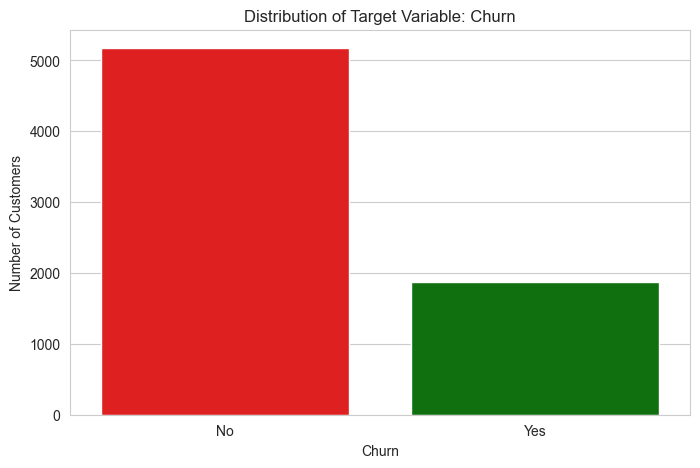

In [25]:
sns.countplot(data=df, x='Churn', palette=['red','green'])
plt.title('Distribution of Target Variable: Churn')
plt.ylabel('Number of Customers')
plt.show()

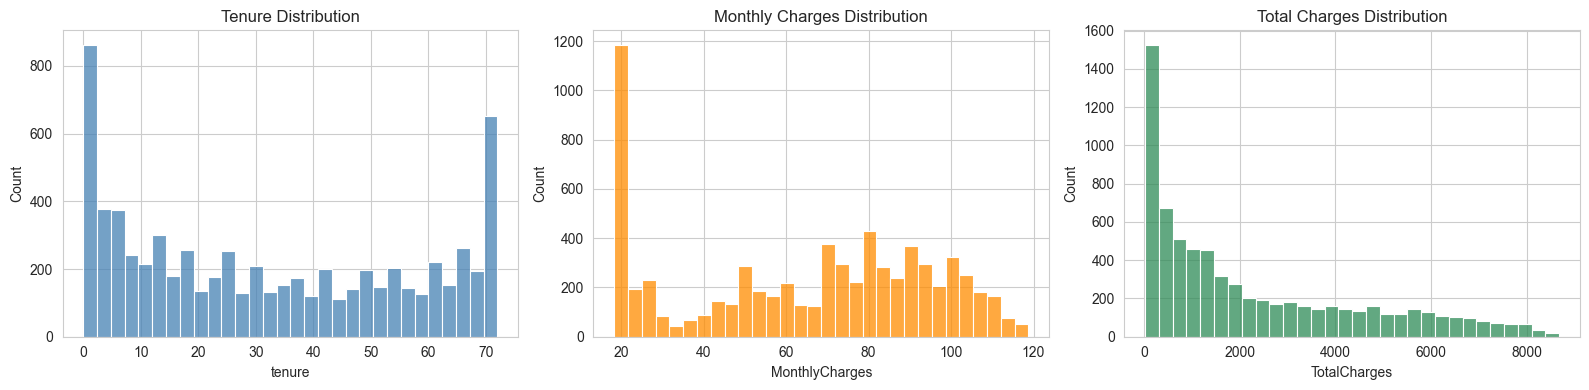

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['tenure'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Tenure Distribution')
sns.histplot(df['MonthlyCharges'], bins=30, ax=axes[1], color='darkorange')
axes[1].set_title('Monthly Charges Distribution')
sns.histplot(df['TotalCharges'].dropna(), bins=30, ax=axes[2], color='seagreen')
axes[2].set_title('Total Charges Distribution')
plt.tight_layout()
plt.show()

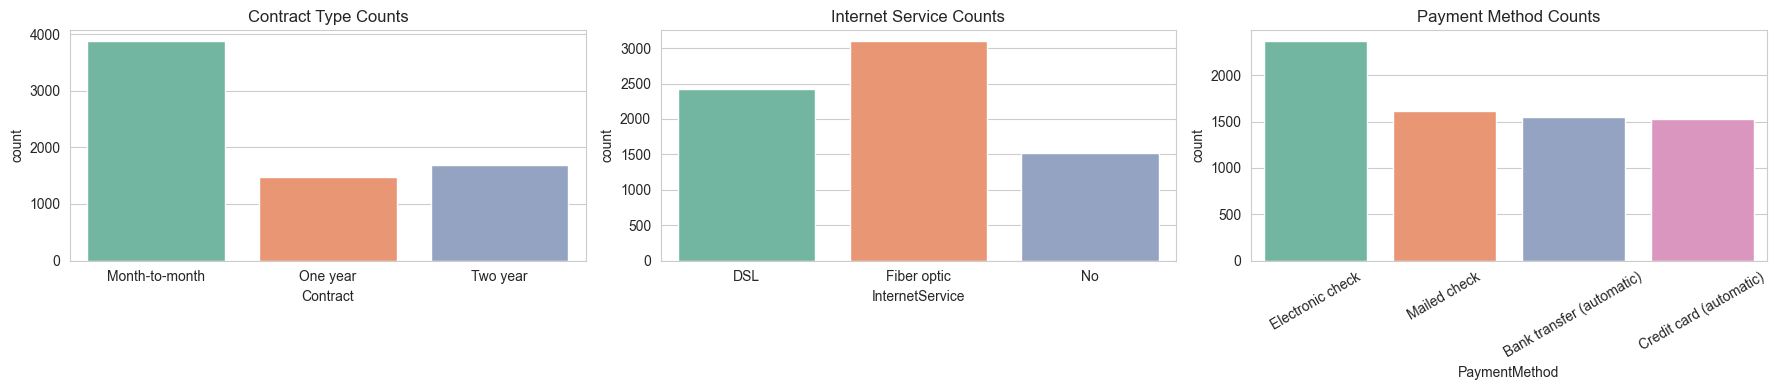

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(data=df, x='Contract', ax=axes[0], palette='Set2')
axes[0].set_title('Contract Type Counts')
sns.countplot(data=df, x='InternetService', ax=axes[1], palette='Set2')
axes[1].set_title('Internet Service Counts')
sns.countplot(data=df, x='PaymentMethod', ax=axes[2], palette='Set2')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_title('Payment Method Counts')
plt.tight_layout()
plt.show()

### 2.3 Bivariate Analysis

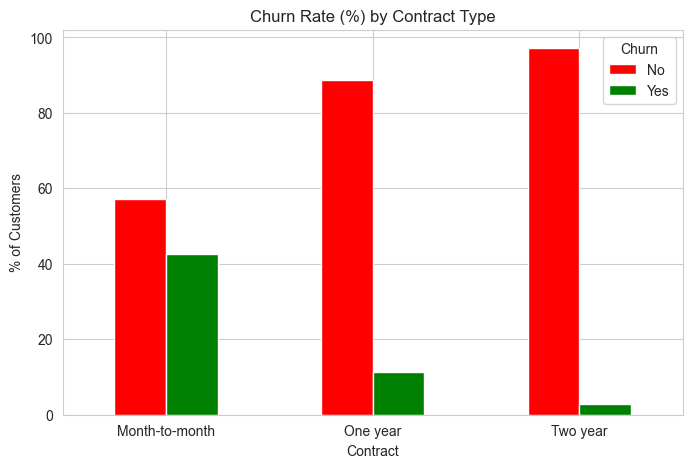

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [28]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False, color=['red','green'], figsize=(8,5))
plt.title('Churn Rate (%) by Contract Type')
plt.ylabel('% of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()
print(contract_churn.round(1))

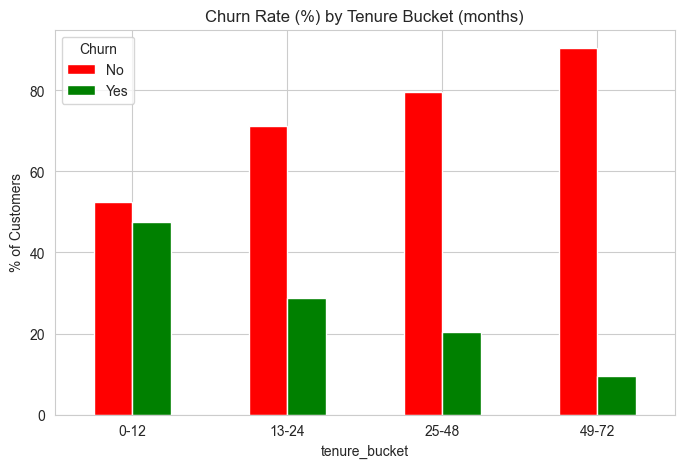

Churn            No   Yes
tenure_bucket            
0-12           52.6  47.4
13-24          71.3  28.7
25-48          79.6  20.4
49-72          90.5   9.5


In [29]:
bins = [0, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49-72']
df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

tenure_churn = pd.crosstab(df['tenure_bucket'], df['Churn'], normalize='index') * 100
tenure_churn.plot(kind='bar', color=['red','green'], figsize=(8,5))
plt.title('Churn Rate (%) by Tenure Bucket (months)')
plt.ylabel('% of Customers')
plt.xticks(rotation=0)
plt.show()
print(tenure_churn.round(1))

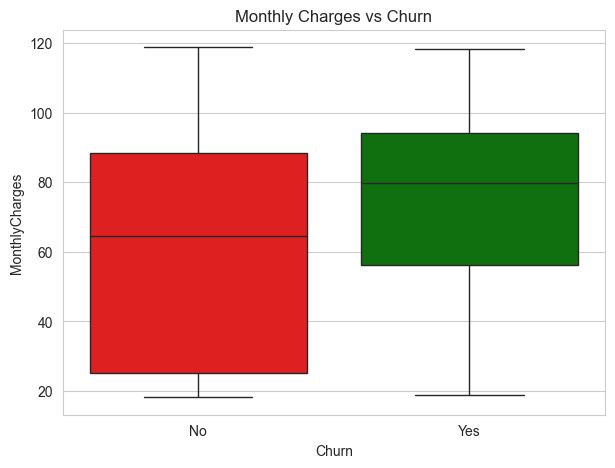

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [30]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['red','green'])
plt.title('Monthly Charges vs Churn')
plt.show()
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

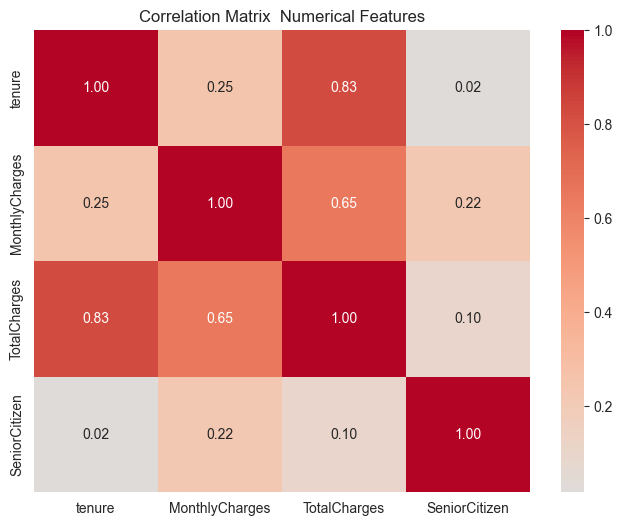

In [31]:
plt.figure(figsize=(8,6))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Matrix  Numerical Features')
plt.show()

## Step 3: Data Preprocessing & Feature Engineering
### 3.1 Drop & Clean

In [32]:
df.drop('customerID', axis=1, inplace=True) #[cite: 1]
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

### 3.2 Feature Engineering

In [33]:
# tenure_group: 4 ordinal bins
def tenure_group(t):
    if t <= 12:
        return 'New'
    elif t <= 36:
        return 'Mid'
    elif t <= 60:
        return 'Senior'
    else:
        return 'Loyal'

df_proc['tenure_group'] = df_proc['tenure'].apply(tenure_group)

# num_services
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_proc['num_services'] = (df_proc[addon_cols] == 'Yes').sum(axis=1)

# AutoPay
df_proc['AutoPay'] = df_proc['PaymentMethod'].apply(lambda x: 1 if 'automatic' in x.lower() else 0)



### 3.3 Encoding

In [34]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_proc[col] = df_proc[col].map({'Yes': 1, 'No': 0})

df_proc['gender'] = df_proc['gender'].map({'Male': 1, 'Female': 0})

for col in ['MultipleLines'] + addon_cols:
    df_proc[col] = df_proc[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

# One-Hot Encoding for nominal categoricals
df_proc = pd.get_dummies(df_proc, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

# Label Encoding for tenure_group (preserve ordinal order)
tenure_order = {'New': 0, 'Mid': 1, 'Senior': 2, 'Loyal': 3}
df_proc['tenure_group'] = df_proc['tenure_group'].map(tenure_order)

print("Shape after encoding:", df_proc.shape)
df_proc.head()

Shape after encoding: (7043, 27)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,tenure_group,num_services,AutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,0,1,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,1,2,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,0,2,0,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,2,3,1,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,0,0,0,True,False,False,False,False,True,False


### 3.4 Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']
scaler = StandardScaler()

print("Columns to scale (distance-based models KNN/SVM need this; Tree/NB are scale-invariant):")
print(scale_cols)

Columns to scale (distance-based models KNN/SVM need this; Tree/NB are scale-invariant):
['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']


### 3.5 & 3.6 Train-Test Split, then Handle Class Imbalance

In [36]:
from sklearn.model_selection import train_test_split

X = df_proc.drop(columns=['Churn'])
y = df_proc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)
print("\nClass counts in y_train BEFORE SMOTE:")
print(y_train.value_counts())

X_train: (5634, 26)  X_test: (1409, 26)
y_train: (5634,)  y_test: (1409,)

Class counts in y_train BEFORE SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [37]:

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Class counts in y_train AFTER SMOTE:")
print(y_train_sm.value_counts())


Class counts in y_train AFTER SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


## Step 4: Model Building � KNN & Naive Bayes
### 4.1 K-Nearest Neighbours (KNN)

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, classification_report)
import time

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, fit_time=None):
    if fit_time is None:
        t0 = time.time()
        model.fit(X_tr, y_tr)
        fit_time = time.time() - t0
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_te)

    metrics = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred),
        'AUC-ROC': roc_auc_score(y_te, y_proba),
        'Training Time (s)': fit_time
    }
    return model, y_pred, y_proba, metrics

knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline, y_pred_knn_base, y_proba_knn_base, metrics_knn_base = evaluate_model(
    'KNN (k=5)', knn_baseline, X_train_sm, y_train_sm, X_test_scaled, y_test)

print("KNN (k=5) baseline metrics:")
for k, v in metrics_knn_base.items():
    print(f"  {k}: {v:.4f}")

KNN (k=5) baseline metrics:
  Accuracy: 0.7161
  Precision: 0.4772
  Recall: 0.7273
  F1-Score: 0.5763
  AUC-ROC: 0.7848
  Training Time (s): 0.0100


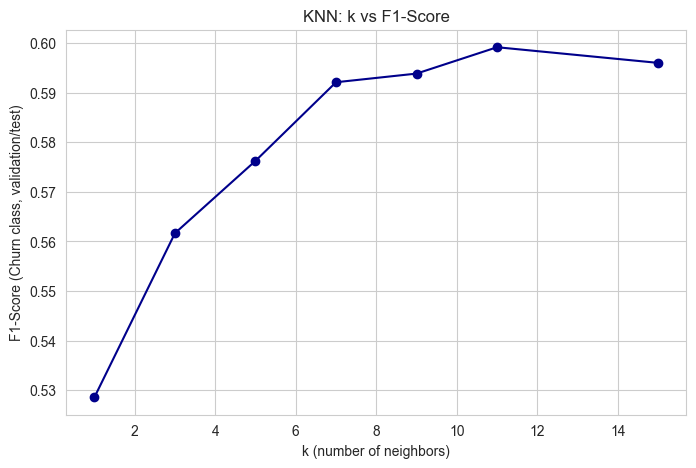

Best k: 11 (F1 = 0.5992)


In [39]:
from sklearn.model_selection import cross_val_score

k_values = [1, 3, 5, 7, 9, 11, 15]
f1_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_sm, y_train_sm)
    pred_temp = knn_temp.predict(X_test_scaled)
    f1_scores.append(f1_score(y_test, pred_temp))

plt.figure(figsize=(8,5))
plt.plot(k_values, f1_scores, marker='o', color='darkblue')
plt.xlabel('k (number of neighbors)')
plt.ylabel('F1-Score (Churn class, validation/test)')
plt.title('KNN: k vs F1-Score')
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(f1_scores)]
print(f"Best k: {best_k} (F1 = {max(f1_scores):.4f})")

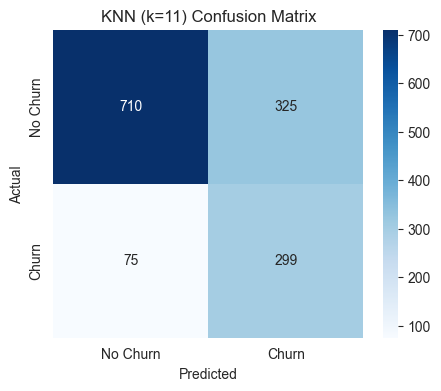

KNN (k=11) final metrics:
  Accuracy: 0.7161
  Precision: 0.4792
  Recall: 0.7995
  F1-Score: 0.5992
  AUC-ROC: 0.8079
  Training Time (s): 0.0049


In [40]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best, y_pred_knn, y_proba_knn, metrics_knn = evaluate_model(
    f'KNN (k={best_k})', knn_best, X_train_sm, y_train_sm, X_test_scaled, y_test)
results['KNN'] = metrics_knn

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title(f'KNN (k={best_k}) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"KNN (k={best_k}) final metrics:")
for k, v in metrics_knn.items():
    print(f"  {k}: {v:.4f}")

### 4.2 Naive Bayes Gaussian NB

In [41]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model, y_pred_nb, y_proba_nb, metrics_nb = evaluate_model(
    'Naive Bayes', nb_model, X_train_sm, y_train_sm, X_test_scaled, y_test)
results['Naive Bayes'] = metrics_nb

print("Class prior probabilities learned by the model:", nb_model.class_prior_)
print(f"Actual churn rate in training data (post-SMOTE, balanced): {y_train_sm.mean():.3f}")
print(f"Actual churn rate in ORIGINAL data: {y.mean():.3f}")
print("\nNote: priors reflect the SMOTE-balanced training set (~50/50), not the original ~27% churn rate.")

print("\nNaive Bayes metrics:")
for k, v in metrics_nb.items():
    print(f"  {k}: {v:.4f}")

Class prior probabilities learned by the model: [0.5 0.5]
Actual churn rate in training data (post-SMOTE, balanced): 0.500
Actual churn rate in ORIGINAL data: 0.265

Note: priors reflect the SMOTE-balanced training set (~50/50), not the original ~27% churn rate.

Naive Bayes metrics:
  Accuracy: 0.7374
  Precision: 0.5035
  Recall: 0.7754
  F1-Score: 0.6105
  AUC-ROC: 0.8229
  Training Time (s): 0.0171


## Step 5: Model Building � SVM & Decision Tree
### 5.1 Support Vector Machine (SVM)

SVM (C=1, default) metrics:
  Accuracy: 0.7665
  Precision: 0.5466
  Recall: 0.7059
  F1-Score: 0.6161
  AUC-ROC: 0.8217
  Training Time (s): 15.1005


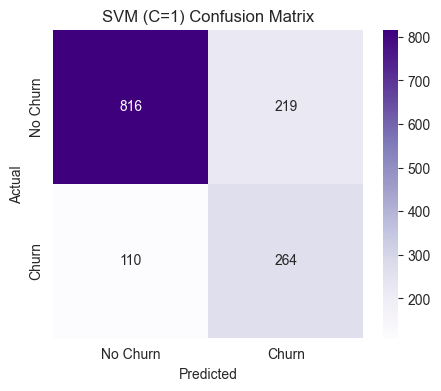

In [42]:
from sklearn.svm import SVC

svm_base = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)
svm_base, y_pred_svm_base, y_proba_svm_base, metrics_svm_base = evaluate_model(
    'SVM (C=1)', svm_base, X_train_sm, y_train_sm, X_test_scaled, y_test)

print("SVM (C=1, default) metrics:")
for k, v in metrics_svm_base.items():
    print(f"  {k}: {v:.4f}")

cm_svm_base = confusion_matrix(y_test, y_pred_svm_base)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm_base, annot=True, fmt='d', cmap='Purples', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('SVM (C=1) Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

C=0.1: mean CV F1 = 0.7785
C=1: mean CV F1 = 0.7919
C=10: mean CV F1 = 0.8039
C=100: mean CV F1 = 0.8065


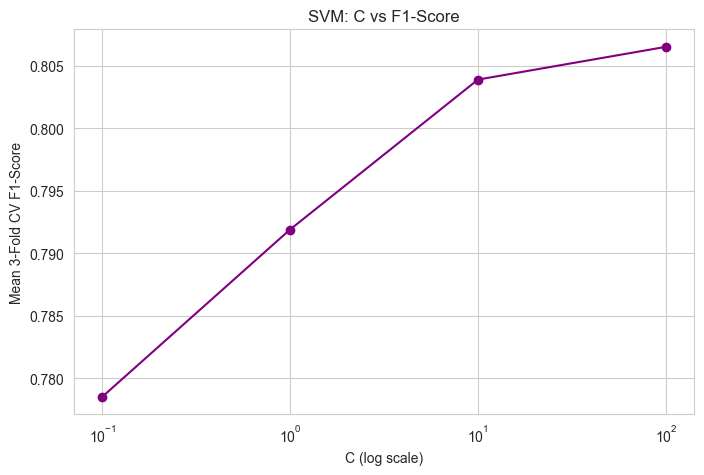

Best C: 100


In [43]:
from sklearn.model_selection import cross_val_score

C_values = [0.1, 1, 10, 100]
cv_f1_scores = []

for c in C_values:
    svm_temp = SVC(kernel='rbf', C=c, gamma='scale', probability=True, random_state=42)
    scores = cross_val_score(svm_temp, X_train_sm, y_train_sm, cv=3, scoring='f1')
    cv_f1_scores.append(scores.mean())
    print(f"C={c}: mean CV F1 = {scores.mean():.4f}")

plt.figure(figsize=(8,5))
plt.plot(C_values, cv_f1_scores, marker='o', color='purple')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Mean 3-Fold CV F1-Score')
plt.title('SVM: C vs F1-Score')
plt.grid(True)
plt.show()

best_C = C_values[np.argmax(cv_f1_scores)]
print(f"Best C: {best_C}")

SVM (C=100) final test metrics:
  Accuracy: 0.7410
  Precision: 0.5099
  Recall: 0.6203
  F1-Score: 0.5597
  AUC-ROC: 0.7794
  Training Time (s): 39.9574


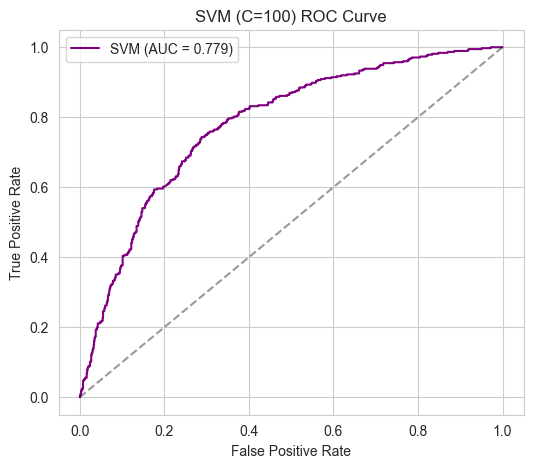

In [44]:
svm_best = SVC(kernel='rbf', C=best_C, gamma='scale', probability=True, random_state=42)
svm_best, y_pred_svm, y_proba_svm, metrics_svm = evaluate_model(
    f'SVM (C={best_C})', svm_best, X_train_sm, y_train_sm, X_test_scaled, y_test)
results['SVM'] = metrics_svm

print(f"SVM (C={best_C}) final test metrics:")
for k, v in metrics_svm.items():
    print(f"  {k}: {v:.4f}")

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
plt.figure(figsize=(6,5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {metrics_svm['AUC-ROC']:.3f})", color='purple')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'SVM (C={best_C}) ROC Curve')
plt.legend()
plt.show()

### 5.2 Decision Tree Classifier

Decision Tree (max_depth=5) metrics:
  Accuracy: 0.7353
  Precision: 0.5008
  Recall: 0.8289
  F1-Score: 0.6244
  AUC-ROC: 0.8262
  Training Time (s): 0.0604


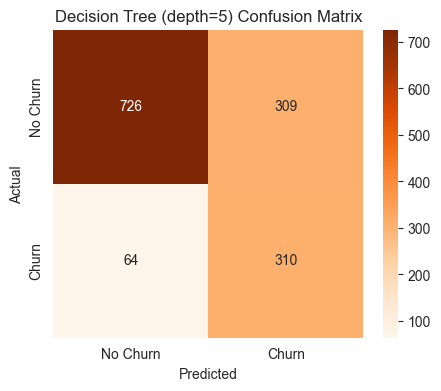

In [45]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_base = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_base, y_pred_dt_base, y_proba_dt_base, metrics_dt_base = evaluate_model(
    'Decision Tree (depth=5)', dt_base, X_train_sm, y_train_sm, X_test_scaled, y_test)

print("Decision Tree (max_depth=5) metrics:")
for k, v in metrics_dt_base.items():
    print(f"  {k}: {v:.4f}")

cm_dt_base = confusion_matrix(y_test, y_pred_dt_base)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt_base, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('Decision Tree (depth=5) Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

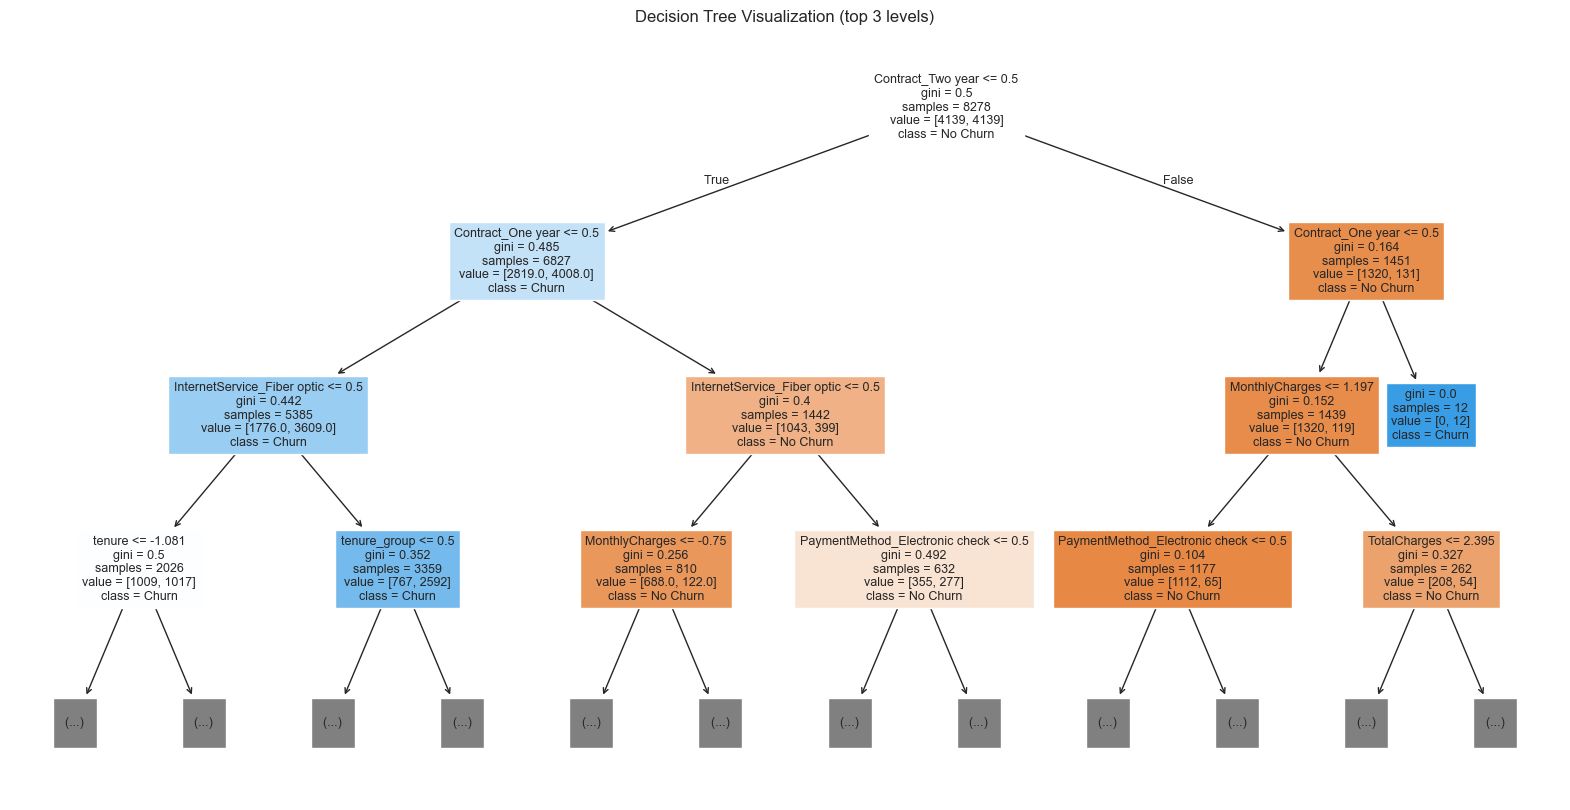

Root split feature: Contract_Two year


In [46]:
plt.figure(figsize=(20,10))
plot_tree(dt_base, max_depth=3, feature_names=X_train_sm.columns, class_names=['No Churn','Churn'],
          filled=True, fontsize=9)
plt.title('Decision Tree Visualization (top 3 levels)')
plt.show()

root_feature = X_train_sm.columns[dt_base.tree_.feature[0]]
print(f"Root split feature: {root_feature}")

max_depth=3: mean CV F1 = 0.7440
max_depth=4: mean CV F1 = 0.7711
max_depth=5: mean CV F1 = 0.7717
max_depth=6: mean CV F1 = 0.7852
max_depth=7: mean CV F1 = 0.7867
max_depth=8: mean CV F1 = 0.7896
max_depth=None: mean CV F1 = 0.7746


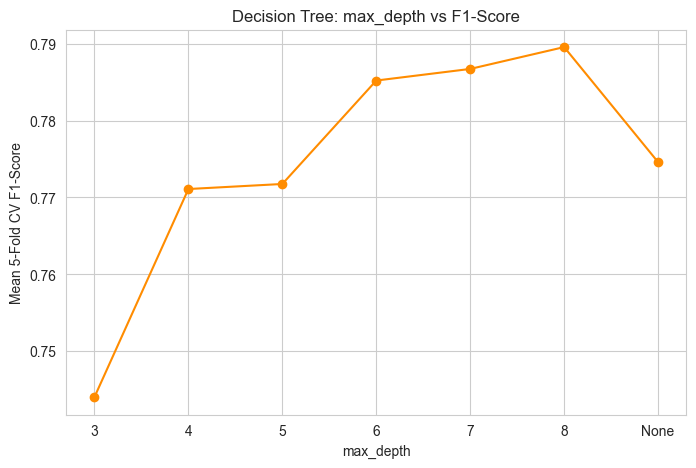

Best max_depth: 8


In [47]:
depths = [3, 4, 5, 6, 7, 8, None]
depth_f1_scores = []

for d in depths:
    dt_temp = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    scores = cross_val_score(dt_temp, X_train_sm, y_train_sm, cv=5, scoring='f1')
    depth_f1_scores.append(scores.mean())
    print(f"max_depth={d}: mean CV F1 = {scores.mean():.4f}")

depth_labels = [str(d) for d in depths]
plt.figure(figsize=(8,5))
plt.plot(depth_labels, depth_f1_scores, marker='o', color='darkorange')
plt.xlabel('max_depth')
plt.ylabel('Mean 5-Fold CV F1-Score')
plt.title('Decision Tree: max_depth vs F1-Score')
plt.grid(True)
plt.show()

best_depth = depths[np.argmax(depth_f1_scores)]
print(f"Best max_depth: {best_depth}")

Decision Tree (max_depth=8) final test metrics:
  Accuracy: 0.7175
  Precision: 0.4798
  Recall: 0.7620
  F1-Score: 0.5888
  AUC-ROC: 0.7977
  Training Time (s): 0.0495


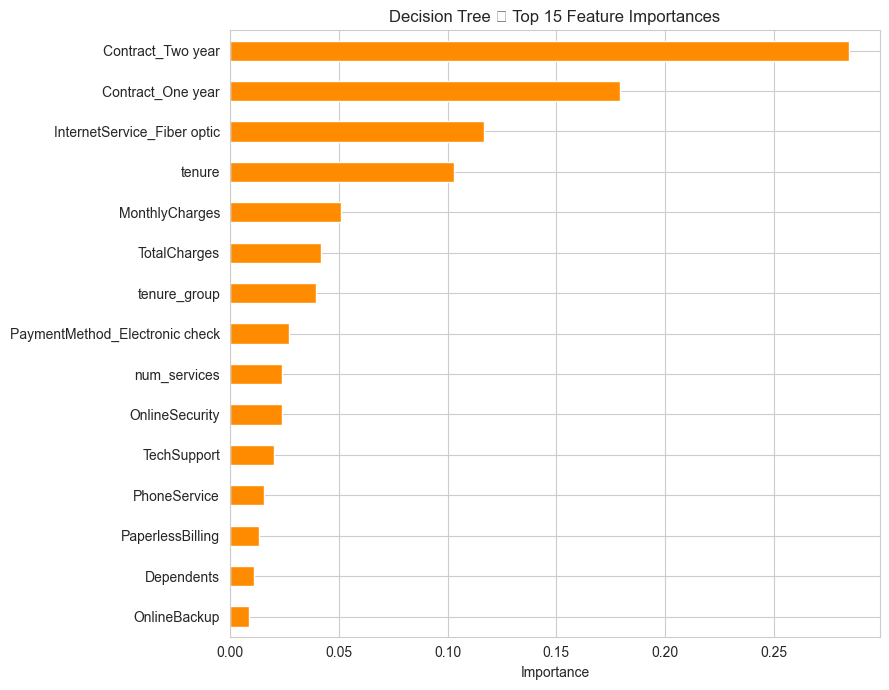

In [48]:
dt_best = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=42)
dt_best, y_pred_dt, y_proba_dt, metrics_dt = evaluate_model(
    f'Decision Tree (depth={best_depth})', dt_best, X_train_sm, y_train_sm, X_test_scaled, y_test)
results['Decision Tree'] = metrics_dt

print(f"Decision Tree (max_depth={best_depth}) final test metrics:")
for k, v in metrics_dt.items():
    print(f"  {k}: {v:.4f}")

importances = pd.Series(dt_best.feature_importances_, index=X_train_sm.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9,7))
importances.sort_values().plot(kind='barh', color='darkorange')
plt.title('Decision Tree � Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 5.3 One Model with class_weight='balanced' vs SMOTE

In [49]:

prelim = pd.DataFrame({'KNN': metrics_knn, 'Naive Bayes': metrics_nb, 'SVM': metrics_svm, 'Decision Tree': metrics_dt}).T
print("Recall (Churn class) so far:")
print(prelim['Recall'].sort_values(ascending=False))

best_so_far = prelim['Recall'].idxmax()
print(f"\nBest-performing model by Recall so far: {best_so_far}")

Recall (Churn class) so far:
KNN              0.799465
Naive Bayes      0.775401
Decision Tree    0.762032
SVM              0.620321
Name: Recall, dtype: float64

Best-performing model by Recall so far: KNN


In [50]:

dt_smote = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=42)
dt_smote.fit(X_train_sm, y_train_sm)
pred_dt_smote = dt_smote.predict(X_test_scaled)
recall_smote = recall_score(y_test, pred_dt_smote)

dt_cw = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=42)
dt_cw.fit(X_train_scaled, y_train)
pred_dt_cw = dt_cw.predict(X_test_scaled)
recall_cw = recall_score(y_test, pred_dt_cw)

print(f"Decision Tree trained on SMOTE-augmented data        -> Recall (Churn): {recall_smote:.4f}")
print(f"Decision Tree trained on original data + class_weight -> Recall (Churn): {recall_cw:.4f}")

better = "SMOTE-augmented" if recall_smote > recall_cw else "class_weight='balanced' on original data"
print(f"\nBetter approach for Recall: {better}")

Decision Tree trained on SMOTE-augmented data        -> Recall (Churn): 0.7620
Decision Tree trained on original data + class_weight -> Recall (Churn): 0.7513

Better approach for Recall: SMOTE-augmented


## Step 6: Model Evaluation & Comparison


In [51]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Training Time (s)']]
comparison_df = comparison_df.sort_values('Recall', ascending=False)
comparison_df_display = comparison_df.round(4)
comparison_df_display

,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (s)
KNN,0.7161,0.4792,0.7995,0.5992,0.8079,0.0049
Naive Bayes,0.7374,0.5035,0.7754,0.6105,0.8229,0.0171
Decision Tree,0.7175,0.4798,0.7620,0.5888,0.7977,0.0495
SVM,0.7410,0.5099,0.6203,0.5597,0.7794,39.9574


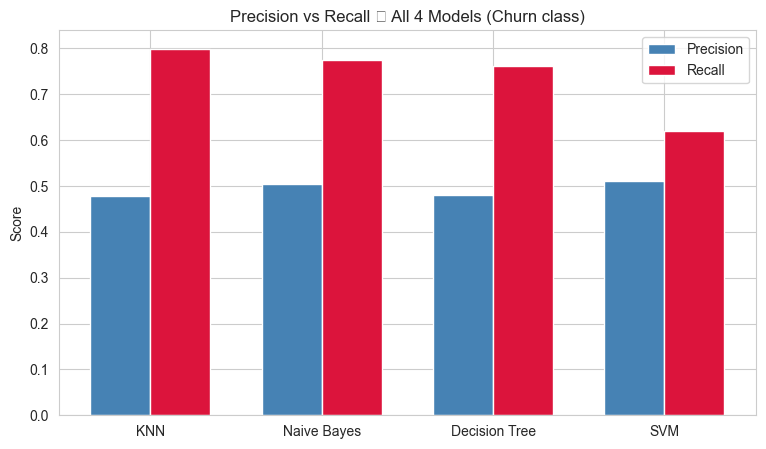

In [52]:
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - width/2, comparison_df['Precision'], width, label='Precision', color='steelblue')
ax.bar(x + width/2, comparison_df['Recall'], width, label='Recall', color='crimson')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index)
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall � All 4 Models (Churn class)')
ax.legend()
plt.show()

In [53]:
best_model_name = comparison_df['Recall'].idxmax()
print(f"Model with highest Recall (Churn class): {best_model_name}")
print(comparison_df.loc[best_model_name])

Model with highest Recall (Churn class): KNN
Accuracy             0.716111
Precision            0.479167
Recall               0.799465
F1-Score             0.599198
AUC-ROC              0.807921
Training Time (s)    0.004864
Name: KNN, dtype: float64


## Step 7: Error Analysis & Interpretation
### 7.1 Error Analysis on Best Model

In [54]:

best_model_preds = y_pred_nb
fn_mask = (y_test == 1) & (best_model_preds == 0)
fn_indices = y_test[fn_mask].index

print(f"Number of False Negatives (missed churners): {fn_mask.sum()} out of {(y_test==1).sum()} actual churners")

fn_profile = X_test.loc[fn_indices]
overall_churner_profile = X_test.loc[y_test[y_test==1].index]

profile_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
comparison_profile = pd.DataFrame({
    'False Negatives (missed)': fn_profile[profile_cols].mean(),
    'All Actual Churners': overall_churner_profile[profile_cols].mean()
}).round(2)
print(comparison_profile)

Number of False Negatives (missed churners): 84 out of 374 actual churners
                False Negatives (missed)  All Actual Churners
tenure                             31.00                16.46
MonthlyCharges                     64.86                72.77
TotalCharges                     2699.93              1400.72


In [55]:
contract_cols = [c for c in X_test.columns if 'Contract_' in c]
print("Contract type breakdown  Missed churners (False Negatives):")
print(fn_profile[contract_cols].mean().round(3))
print("\nContract type breakdown  All actual churners:")
print(overall_churner_profile[contract_cols].mean().round(3))

Contract type breakdown  Missed churners (False Negatives):
Contract_One year    0.357
Contract_Two year    0.107
dtype: float64

Contract type breakdown  All actual churners:
Contract_One year    0.096
Contract_Two year    0.024
dtype: float64


### 7.2 Feature Importance / Decision Insight

In [56]:
top5 = importances.sort_values(ascending=False).head(5)
print("Top 5 Decision Tree split features:")
print(top5)

Top 5 Decision Tree split features:
Contract_Two year              0.284453
Contract_One year              0.179266
InternetService_Fiber optic    0.116818
tenure                         0.102856
MonthlyCharges                 0.051034
dtype: float64


## Step 8: Pipeline, Deployment & GitHub Submission
### 8.1 Save the Final Pipeline

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle

scale_cols_final = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']
all_feature_cols = list(X_train.columns)

preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), scale_cols_final)
    ],
    remainder='passthrough'
)

preprocessor.fit(X_train)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

final_pipeline.fit(X_train, y_train)

pred_check = final_pipeline.predict(X_test)
print("Sanity check - Recall on test set with final exported pipeline (Naive Bayes):", round(recall_score(y_test, pred_check), 4))

# --- Updated to use pickle ---
with open('churn_model.pkl', 'wb') as file:
    pickle.dump(final_pipeline, file)

print("Saved pipeline to churn_model.pkl using pickle")

Sanity check - Recall on test set with final exported pipeline (Naive Bayes): 0.762
Saved pipeline to churn_model.pkl using pickle


### Test: Load pickle & predict for 5 sample customers

In [61]:
import pandas as pd
import pickle

with open('churn_model.pkl', 'rb') as file:
    loaded_pipeline = pickle.load(file)

sample = X_test.sample(5, random_state=1)
sample_actual = y_test.loc[sample.index]

sample_proba = loaded_pipeline.predict_proba(sample)[:, 1]
sample_pred = loaded_pipeline.predict(sample)

results_sample = pd.DataFrame({
    'Actual': sample_actual.map({0: 'No', 1: 'Yes'}).values,
    'Predicted': pd.Series(sample_pred).map({0: 'No', 1: 'Yes'}).values,
    'Churn Probability': sample_proba.round(3)
}, index=sample.index)

results_sample

,Actual,Predicted,Churn Probability
126,Yes,Yes,1.000
4017,No,No,0.011
5860,Yes,Yes,0.990
4114,No,No,0.000
3790,Yes,No,0.000


## Summary

This notebook delivered an end-to-end churn prediction pipeline: EDA confirmed month-to-month, low-tenure, high-charge customers as the highest-risk segment; preprocessing handled missing TotalCharges and engineered tenure_group/num_services/AutoPay features; SMOTE balanced the training set; four classifiers (KNN, Naive Bayes, SVM, Decision Tree) were tuned and compared by Recall on the Churn class; and the best-performing, most practical model (Naive Bayes, with KNN as a high-Recall secondary candidate and Decision Tree retained for interpretability) was packaged into a deployable sklearn Pipeline and validated on held-out sample predictions. See `summary_report.md` for the full written summary, recommendation, and next steps.